# Error mitigation

Perceval offers natively some mitigation techniques, that try to get the noisy results closer to the expected noiseless results by applying some corrections. They rely on extra measurements with different parameters than the original experiment. Some of them will create several sub-jobs and combine them to get better approximations of the results.

There exist algorithms for different purposes:
- HOM and g2 mitigation
- Loss mitigation
- Compilation/phase error averaging
- Detector balancing

It is worth noting that, in a noiseless environment (such as noiseless simulators), these techniques should not be used, as they will slow down the whole process without bringing better results. Also, some techniques are not compatible with non-unitary Experiments, including feed-forwarded Experiments, or have some restrictions on parameters (for example, the loss mitigation can't be used if there are less than 3 requested photons).

Last but not least, these techniques work by combining some results, so they might require many samples to properly run on a real QPU, and will only mitigate the results. Although some techniques will correct every error perfectly in simulation, this will not be the case on real hardware as they are limited by how well the hardware deviates from its characterization.

Some of these techniques may also be computationally heavy, depending on the size of the output space and the number of photons.

In [1]:
from perceval import (Experiment, BS, FockState, pdisplay, SimulatedComputer, NoiseModel, RemoteComputer,
                      ExecutionFactory,
                      Detector, MitigationFactory, MitigationLevel, DetectorBalancing, DistinguishablePhotonMitigation,
                      QuandelaCommunicationLayer)

## Basic example

We will take a simple HOM experiment, and show that our mitigation techniques manage to get closer to the perfect distribution.

As a reminder, for an HOM experiment, we take a single beam splitter and inject 1 photon into each mode |1,1>. We then expect to see 50% of |2, 0> and 50% of |0, 2>.

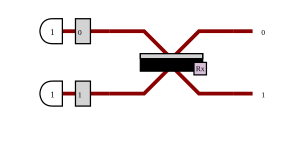

In [2]:
# Start as usual by defining your Experiment

e = Experiment(2)
e.add(0, BS())
e.with_input(FockState([1, 1]))
e.min_detected_photons_filter(2)

pdisplay(e)

In [3]:
# As a reminder, we can compute for the perfect case like this
comp = SimulatedComputer("SLOS")
comp.start()

exec = ExecutionFactory(comp, e).probs
print(exec())

{'results': {
	|2,0>: 0.5
	|0,2>: 0.5
}, 'global_perf': 1.0000000000000004}


Now, we are going to add some noise and imperfect detectors, and investigate how different mitigation techniques can be combined to get better results.

In [4]:
comp.noise = NoiseModel(indistinguishability=0.8, g2=0.03)

# Add imbalanced detectors in the experiment
e.add(0, Detector.ppnr(4, wire_efficiency=0.87))
e.add(1, Detector.ppnr(8, wire_efficiency=0.76))

# That's all, we can now do as before
exec = ExecutionFactory(comp, e).probs
pdisplay(exec()['results'], max_v = 5)

state,probability
"|2,0>",0.452779
"|0,2>",0.402031
"|1,1>",0.125265
"|1,2>",0.006667
"|2,1>",0.006549


We can see that many unwanted states appeared, as we only get a desired state 85.4% of the time, and that the wanted probabilities are not equal due to the detector unbalance. We are going to use some mitigation to fix this.

The mitigations are defined at the Computer level, so that they can go along with the noise. The easiest way to add mitigation techniques is to use the MitigationFactory, but we'll see later how to add custom mitigations.

In [5]:
# The highest the level, the more mitigations are applied, but the more expensive they become
comp.mitigations = MitigationFactory(MitigationLevel.medium).build()

# That's all, we can now do as before
exec = ExecutionFactory(comp, e).probs
print(exec())

{'results': {
	|2,0>: 0.5
	|0,2>: 0.5
}, 'global_perf': 1.0000000000000007}


We can see that, in this example using strong simulation, the mitigation techniques perfectly corrected the errors. Now, we are going to see how to define the mitigations by yourself.

## Advanced example

In our example, we only set HOM, g2 and detector imbalance errors. Let's investigate on how we can combine the mitigations for these kind of errors by choosing them by hand.

In [6]:
# As a starting point, we will use detector balancing only
comp.mitigations = [DetectorBalancing()]

exec = ExecutionFactory(comp, e).probs
pdisplay(exec()["results"], max_v = 5)

state,probability
"|2,0>",0.436187
"|0,2>",0.436187
"|1,1>",0.09693
"|1,2>",0.008376
"|2,1>",0.008376


We can see that this fixed the imbalance imposed by the detectors, and increased the probability of getting a wanted state to 87.2%.

In [7]:
# Now, we use HOM and g2 mitigations only

# Order is the number of photons that we will remove on sub-jobs.
# The higher the order, the better the results, but the number of sub-jobs increases as the sum of (n choose k) where k is all the values up to order
dist_mitigation = DistinguishablePhotonMitigation(order=1)
print(f"The total number of computations will be: {dist_mitigation.overhead(e.input_state)}")

The total number of computations will be: 3


In [8]:
# Do the computation
comp.mitigations = [dist_mitigation]

exec = ExecutionFactory(comp, e).probs
pdisplay(exec()["results"], max_v = 5)

state,probability
"|2,0>",0.517868
"|0,2>",0.471126
"|1,1>",0.011006


In this case, we got a far better success rate, which is at 98.9%, but using distinguishable photon mitigation alone can't compensate for the detector imbalance.

Finally, we can use both at the same time. Note that the order of application of the mitigations matter.

Mitigations are applied left to right, meaning that each sub-job generated by a mitigation is fed to the next mitigation of the list. As such, it is advised not to repeat a given mitigation technique, and to use the same order as provided by the MitigationFactory

In [9]:
# To emphasize the difference when applying the mitigations in different order

# We can also change the noise or the mitigations for a limited scope
with comp.apply_configuration(mitigations=[DetectorBalancing(), dist_mitigation]):
    exec = ExecutionFactory(comp, e).probs
    pdisplay(exec()["results"], max_v = 5)

state,probability
"|0,2>",0.50088
"|2,0>",0.490176
"|1,1>",0.008944


In this order, we get better results than with only one mitigation, but we still have a 0.1% failure rate. Also, we didn't perfectly correct for the imbalance.

In [10]:
# Using the MitigationFactory order, configuring it by hand
mitigation_factory = MitigationFactory(MitigationLevel.none)

# The call order of these methods doesn't matter
mitigation_factory.set_custom_mitigation(dist_mitigation)
mitigation_factory.set_detector_balancing()

with comp.apply_configuration(mitigations=mitigation_factory.build()):
    exec = ExecutionFactory(comp, e).probs
    pdisplay(exec()["results"], max_v = 5)

state,probability
"|2,0>",1/2
"|0,2>",1/2


We got exactly what we wanted!

In [11]:
comp.stop()

## Remote Mitigation

When using RemoteComputer, a few things can change with error mitigation.

First, some QPUs may have a default mitigation, which is applied if nothing is specified. If a mitigation is manually given, it replaces the default mitigation, including if the given mitigation is empty.

Then, the mitigated Execution is sent to the cloud as a single job, and everything happens remotely if the target knows all the mitigations. Else, the mitigations happen locally and may generate several jobs. If needed, the local application of the mitigations can be enforced.

In [12]:
comp = RemoteComputer(QuandelaCommunicationLayer("qpu:belenos"))

print(comp.specs.default_mitigations)

[]


In [ ]:
# Here, the mitigation would be sent with a single cloud job
exec = ExecutionFactory(comp, e, max_shots_per_call=100_000).probs

# We can change this behaviour and apply the mitigations locally.
# In this case, several jobs may be sent to the cloud and the postprocessing happens locally
# comp.use_mitigations_remotely = False

with comp.acquire():
    res = exec(max_samples = 10_000)

pdisplay(res["results"], max_v = 5)

It is also worth mentioning that the number of samples received at the end of a mitigated job may not correspond to the actual number of samples. Also, the number of shots is split between all sub-jobs, so the total number of shots will never exceed the requested number of shots.